In [64]:
# 1. import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from skimage import measure
from skimage.morphology import binary_closing, ball
import trimesh
import pyvista as pv

In [65]:
# 2. set paths

processed_path = r"E:\apply\journal publication\tnbc-diffusion\data\processed"
figures_path = r"E:\apply\journal publication\tnbc-diffusion\outputs\figures"
meshes_path = r"E:\apply\journal publication\tnbc-diffusion\outputs\meshes"

os.makedirs(meshes_path, exist_ok=True)

summary = pd.read_csv(os.path.join(processed_path, "batch_processing_summary.csv"))
clinical = pd.read_csv(os.path.join(processed_path, "tnbc_imaging_clinical.csv"))

print("patients:", len(summary))
print("columns:", clinical.columns.tolist())

patients: 16
columns: ['patient_id', 'status', 'mask_value', 'tumor_voxels', 'tumor_volume_cc', 'pixel_spacing_mm', 'slice_thickness_mm', 'n_slices', 'dce_timeframes', 'dce_shape', 'Patient_ID', 'Arm', 'HR', 'HER2', 'MP', 'pCR', 'Age_at_Screening', 'Race', 'menopausal_status', 'ethnicity', 'VOLUME_TUM_BLU_V10', 'VOLUME_TUM_BLU_V20', 'VOLUME_TUM_BLU_V30', 'VOLUME_TUM_BLU_V40', 'SPHERICITY_T0', 'SPHERICITY_T1', 'SPHERICITY_T2', 'SPHERICITY_T3', 'LD_T0', 'LD_T1', 'LD_T2', 'LD_T3', 'BPE_5slice_mean_T0', 'BPE_5slice_mean_T1', 'BPE_5slice_mean_T2', 'BPE_5slice_mean_T3', 'FTV_pch_T0_T1', 'FTV_pch_T0_T2', 'FTV_pch_T0_T3', 'Sphericity_pch_T0_T1', 'Sphericity_pch_T0_T2', 'Sphericity_pch_T0_T3', 'LD_pch_T0_T1', 'LD_pch_T0_T2', 'LD_pch_T0_T3', 'BPE_pch_T0_T1', 'BPE_pch_T0_T2', 'BPE_pch_T0_T3']


In [66]:
# 3. function to generate surface mesh from tumor mask

def mask_to_mesh(tumor_mask, pixel_spacing, slice_thickness, patient_id, save_dir):
    closed_mask = binary_closing(tumor_mask, ball(2)).astype(np.uint8)
    verts, faces, normals, values = measure.marching_cubes(
        closed_mask,
        level=0.5,
        spacing=(slice_thickness, pixel_spacing, pixel_spacing)
    )
    mesh = trimesh.Trimesh(vertices=verts, faces=faces, vertex_normals=normals)
    mesh = trimesh.smoothing.filter_laplacian(mesh, lamb=0.5, iterations=10)
    save_path = os.path.join(save_dir, patient_id + "_tumor_mesh.stl")
    mesh.export(save_path)
    return mesh, save_path

In [67]:
# 4. generate meshes for all patients

mesh_results = []

for idx, row in summary.iterrows():
    patient_id = row["patient_id"]
    pid = patient_id.replace("ISPY2-", "")

    mask_file = os.path.join(processed_path, "tumor_mask_" + pid + "_T0.npy")
    if not os.path.exists(mask_file):
        print("mask not found for:", patient_id)
        continue

    tumor_mask = np.load(mask_file)
    pixel_spacing = row["pixel_spacing_mm"]
    slice_thickness = row["slice_thickness_mm"]

    mesh, save_path = mask_to_mesh(tumor_mask, pixel_spacing, slice_thickness, pid, meshes_path)

    mesh_results.append({
        "patient_id": patient_id,
        "pid": pid,
        "vertices": len(mesh.vertices),
        "faces": len(mesh.faces),
        "volume_cc": round(mesh.volume / 1000, 4),
        "is_watertight": mesh.is_watertight,
        "mesh_path": save_path
    })

    print(patient_id, "vertices:", len(mesh.vertices), "watertight:", mesh.is_watertight)

mesh_df = pd.DataFrame(mesh_results)
mesh_df.to_csv(os.path.join(processed_path, "mesh_summary.csv"), index=False)
print("done")

ISPY2-164468 vertices: 55504 watertight: False
ISPY2-196024 vertices: 31113 watertight: False
ISPY2-208303 vertices: 32760 watertight: False
ISPY2-252748 vertices: 138935 watertight: False
ISPY2-489504 vertices: 18853 watertight: True


c:\Users\Koush\AppData\Local\Programs\Python\Python310\lib\site-packages\trimesh\smoothing.py:92: RuntimeWarning: invalid value encountered in scalar power
  vertices *= (vol_ini / vol_new) ** (1.0 / 3.0)


ISPY2-502486 vertices: 74374 watertight: False
ISPY2-535779 vertices: 14493 watertight: False
ISPY2-564234 vertices: 11440 watertight: True
ISPY2-578975 vertices: 60070 watertight: True
ISPY2-622315 vertices: 97755 watertight: False
ISPY2-625854 vertices: 22182 watertight: False
ISPY2-697098 vertices: 62376 watertight: False
ISPY2-727804 vertices: 77030 watertight: False
ISPY2-829491 vertices: 34283 watertight: True
ISPY2-910706 vertices: 27185 watertight: False
ISPY2-934906 vertices: 16165 watertight: False
done


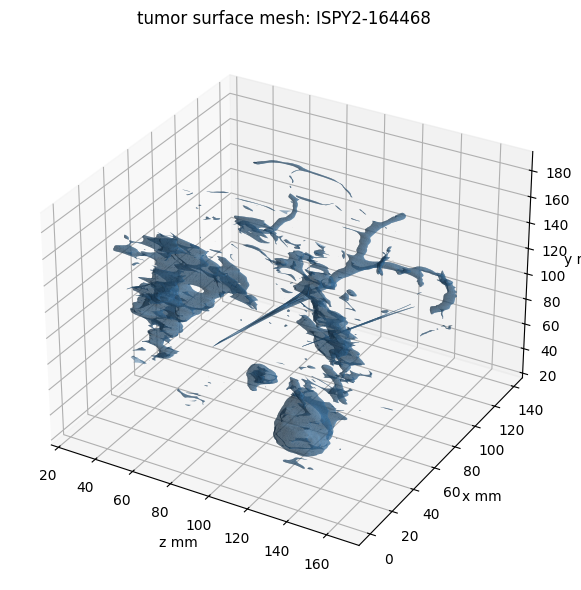

In [68]:
# 5. visualise one mesh

pid = "164468"
mesh = trimesh.load(os.path.join(meshes_path, pid + "_tumor_mesh.stl"))

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_trisurf(
    mesh.vertices[:, 0],
    mesh.vertices[:, 1],
    mesh.vertices[:, 2],
    triangles=mesh.faces,
    alpha=0.6,
    color="steelblue"
)
ax.set_title("tumor surface mesh: ISPY2-164468")
ax.set_xlabel("z mm")
ax.set_ylabel("x mm")
ax.set_zlabel("y mm")
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "tumor_mesh_164468.png"), dpi=300)
plt.show()

In [69]:
# 6. print mesh summary

print(mesh_df[["patient_id", "vertices", "faces", "volume_cc", "is_watertight"]])

      patient_id  vertices   faces  volume_cc  is_watertight
0   ISPY2-164468     55504  111682   -40.2320          False
1   ISPY2-196024     31113   62038   -14.3879          False
2   ISPY2-208303     32760   52294    -1.0000          False
3   ISPY2-252748    138935  226810    -8.3059          False
4   ISPY2-489504     18853   37814   -36.1713           True
5   ISPY2-502486     74374  116832        NaN          False
6   ISPY2-535779     14493   22416    -0.4051          False
7   ISPY2-564234     11440   22912   -14.4058           True
8   ISPY2-578975     60070  121448   -50.7648           True
9   ISPY2-622315     97755  194462   -14.0842          False
10  ISPY2-625854     22182   34677    -0.4851          False
11  ISPY2-697098     62376  124222   -25.9224          False
12  ISPY2-727804     77030  125910    -7.9694          False
13  ISPY2-829491     34283   56338    -2.0014           True
14  ISPY2-910706     27185   54918   -50.4305          False
15  ISPY2-934906     161

In [70]:
# 7. mesh repair

def load_mesh(path):
    loaded = trimesh.load(path)
    if isinstance(loaded, trimesh.Scene):
        meshes = list(loaded.geometry.values())
        if len(meshes) == 0:
            return None
        loaded = meshes[0]
    if not isinstance(loaded, trimesh.Trimesh):
        return None
    return loaded

def fix_mesh(mesh):
    if mesh is None or len(mesh.vertices) == 0 or len(mesh.faces) == 0:
        return None
    trimesh.repair.fix_normals(mesh)
    trimesh.repair.fix_winding(mesh)
    trimesh.repair.fill_holes(mesh)
    try:
        if mesh.volume < 0:
            mesh.invert()
    except Exception:
        pass
    return mesh

fixed_results = []

for idx, row in mesh_df.iterrows():
    pid = row["pid"]
    mesh_path = row["mesh_path"]
    mesh = load_mesh(mesh_path)
    mesh = fix_mesh(mesh)

    if mesh is None:
        print(row["patient_id"], "skipped")
        fixed_results.append({
            "patient_id": row["patient_id"],
            "pid": pid,
            "vertices": 0,
            "faces": 0,
            "volume_cc": None,
            "is_watertight": False,
            "status": "skipped"
        })
        continue

    mesh.export(mesh_path)
    fixed_results.append({
        "patient_id": row["patient_id"],
        "pid": pid,
        "vertices": len(mesh.vertices),
        "faces": len(mesh.faces),
        "volume_cc": round(mesh.volume / 1000, 4) if mesh.is_watertight else None,
        "is_watertight": mesh.is_watertight,
        "status": "ok"
    })
    print(row["patient_id"], "watertight:", mesh.is_watertight, "vertices:", len(mesh.vertices))

fixed_df = pd.DataFrame(fixed_results)
fixed_df.to_csv(os.path.join(processed_path, "mesh_fixed_summary.csv"), index=False)
print("done")

ISPY2-164468 watertight: False vertices: 55504
ISPY2-196024 watertight: False vertices: 31113
ISPY2-208303 watertight: False vertices: 32760
ISPY2-252748 watertight: False vertices: 138935
ISPY2-489504 watertight: True vertices: 18853
ISPY2-502486 skipped
ISPY2-535779 watertight: False vertices: 14493
ISPY2-564234 watertight: True vertices: 11440
ISPY2-578975 watertight: True vertices: 60070
ISPY2-622315 watertight: False vertices: 97755
ISPY2-625854 watertight: False vertices: 22182
ISPY2-697098 watertight: False vertices: 62376
ISPY2-727804 watertight: False vertices: 77030
ISPY2-829491 watertight: True vertices: 34283
ISPY2-910706 watertight: False vertices: 27185
ISPY2-934906 watertight: False vertices: 16165
done


In [71]:
# 8. print fixed mesh summary

print(fixed_df[["patient_id", "vertices", "volume_cc", "is_watertight", "status"]])

      patient_id  vertices  volume_cc  is_watertight   status
0   ISPY2-164468     55504        NaN          False       ok
1   ISPY2-196024     31113        NaN          False       ok
2   ISPY2-208303     32760        NaN          False       ok
3   ISPY2-252748    138935        NaN          False       ok
4   ISPY2-489504     18853    36.1713           True       ok
5   ISPY2-502486         0        NaN          False  skipped
6   ISPY2-535779     14493        NaN          False       ok
7   ISPY2-564234     11440    14.4058           True       ok
8   ISPY2-578975     60070    50.7648           True       ok
9   ISPY2-622315     97755        NaN          False       ok
10  ISPY2-625854     22182        NaN          False       ok
11  ISPY2-697098     62376        NaN          False       ok
12  ISPY2-727804     77030        NaN          False       ok
13  ISPY2-829491     34283     2.0014           True       ok
14  ISPY2-910706     27185        NaN          False       ok
15  ISPY

In [72]:
# 9. set up pde parameters from paper

params = {
    "D_n": 1.0e-4,
    "D_c": 1.5e-3,
    "D_d": 8.6e-4,
    "r": 0.20,
    "K": 1.0e8,
    "alpha": 2.0e-9,
    "beta": 0.10,
    "gamma": 1.00,
    "c0": 40.0,
    "c_crit": 5.0,
    "d_thr": 0.10,
    "d_peak": 1.00
}

params_sim = {
    "D_n": 1.0e-4,
    "D_c": 1.5e-3,
    "D_d": 5.0e-2,
    "r": 0.20,
    "K": 1.0e8,
    "alpha": 2.0e-9,
    "beta": 0.10,
    "gamma": 0.01,
    "c0": 40.0,
    "c_crit": 5.0,
    "d_thr": 0.10,
    "d_peak": 1.00
}

L_d = np.sqrt(params["D_d"] / params["gamma"])
L_d_sim = np.sqrt(params_sim["D_d"] / params_sim["gamma"])
c_min = 2 * np.sqrt(params["D_n"] * params["r"])
P_star_base = (1 / params["gamma"]) * np.log(params["d_peak"] / params["d_thr"])

print("theoretical L_d from paper params:", round(L_d * 10, 4), "mm")
print("simulation L_d:", round(L_d_sim * 10, 4), "mm")
print("minimum wave speed c_min:", round(c_min, 6), "cm per day")
print("critical period P_star base:", round(P_star_base, 4), "days")

theoretical L_d from paper params: 0.2933 mm
simulation L_d: 22.3607 mm
minimum wave speed c_min: 0.008944 cm per day
critical period P_star base: 2.3026 days


In [76]:
# 10. pde solver using pytorch gpu acceleration

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:", device)

def get_bounding_box(mask, margin=10):
    coords = np.argwhere(mask > 0)
    z_min, y_min, x_min = coords.min(axis=0)
    z_max, y_max, x_max = coords.max(axis=0)
    z_min = max(0, z_min - margin)
    y_min = max(0, y_min - margin)
    x_min = max(0, x_min - margin)
    z_max = min(mask.shape[0], z_max + margin)
    y_max = min(mask.shape[1], y_max + margin)
    x_max = min(mask.shape[2], x_max + margin)
    return z_min, z_max, y_min, y_max, x_min, x_max

def torch_laplace(arr):
    result = torch.zeros_like(arr)
    result[1:-1, 1:-1, 1:-1] = (
        arr[2:, 1:-1, 1:-1] + arr[:-2, 1:-1, 1:-1] +
        arr[1:-1, 2:, 1:-1] + arr[1:-1, :-2, 1:-1] +
        arr[1:-1, 1:-1, 2:] + arr[1:-1, 1:-1, :-2] -
        6 * arr[1:-1, 1:-1, 1:-1]
    )
    return result

def run_pde_solver(tumor_mask, params, pixel_spacing, slice_thickness, n_days=84, dt=0.1):
    z_min, z_max, y_min, y_max, x_min, x_max = get_bounding_box(tumor_mask, margin=10)
    mask_crop = tumor_mask[z_min:z_max, y_min:y_max, x_min:x_max]

    nz, ny, nx = mask_crop.shape
    dx = pixel_spacing / 10

    n = torch.tensor(mask_crop.astype(float) * params["K"] * 0.5, dtype=torch.float32, device=device)
    c = torch.ones((nz, ny, nx), dtype=torch.float32, device=device) * params["c0"]
    d = torch.zeros((nz, ny, nx), dtype=torch.float32, device=device)

    boundary = torch.zeros((nz, ny, nx), dtype=torch.float32, device=device)
    boundary[0, :, :] = 1
    boundary[-1, :, :] = 1
    boundary[:, 0, :] = 1
    boundary[:, -1, :] = 1
    boundary[:, :, 0] = 1
    boundary[:, :, -1] = 1

    n_steps = int(n_days / dt)
    dose_days = list(range(0, n_days, 21))

    n_history = []
    c_history = []
    d_history = []
    save_steps = [0, n_steps // 4, n_steps // 2, n_steps - 1]

    for step in range(n_steps):
        current_day = step * dt

        boundary_dose = 0.0
        for dose_day in dose_days:
            if abs(current_day - dose_day) < dt:
                boundary_dose = params["d_peak"]
                break

        c[boundary == 1] = params["c0"]
        d[boundary == 1] = boundary_dose

        lap_n = torch_laplace(n) / (dx ** 2)
        lap_c = torch_laplace(c) / (dx ** 2)
        lap_d = torch_laplace(d) / (dx ** 2)

        dn = (params["D_n"] * lap_n +
              params["r"] * n * (1 - n / params["K"]) -
              params["beta"] * n * d) * dt

        dc = (params["D_c"] * lap_c -
              params["alpha"] * n * c) * dt

        dd = (params["D_d"] * lap_d -
              params["gamma"] * d) * dt

        n = torch.clamp(n + dn, 0, params["K"])
        c = torch.clamp(c + dc, 0, params["c0"])
        d = torch.clamp(d + dd, 0, params["d_peak"])

        if step in save_steps:
            n_history.append(n.cpu().numpy())
            c_history.append(c.cpu().numpy())
            d_history.append(d.cpu().numpy())

    return n_history, c_history, d_history, mask_crop

using device: cuda


In [77]:
# 11. run pde solver on first patient as test

pid = "164468"
tumor_mask = np.load(os.path.join(processed_path, "tumor_mask_" + pid + "_T0.npy"))

pixel_spacing = float(summary[summary["patient_id"] == "ISPY2-" + pid]["pixel_spacing_mm"].values[0])
slice_thickness = float(summary[summary["patient_id"] == "ISPY2-" + pid]["slice_thickness_mm"].values[0])

print("running pde solver for patient", pid)
print("full mask shape:", tumor_mask.shape)

n_hist, c_hist, d_hist, mask_crop = run_pde_solver(tumor_mask, params_sim, pixel_spacing, slice_thickness)

print("solver finished")
print("cropped domain shape:", mask_crop.shape)
print("saved time points:", len(n_hist))

running pde solver for patient 164468
full mask shape: (72, 256, 256)
solver finished
cropped domain shape: (71, 196, 240)
saved time points: 4


In [85]:
# 12. compute failure zone from pde output

def compute_failure_zone(c_hist, d_hist, params, mask_crop):
    failure_zones = []
    for c_field, d_field in zip(c_hist, d_hist):
        fz = ((c_field < params["c_crit"]) &
              (d_field < params["d_thr"]) &
              (mask_crop > 0)).astype(np.uint8)
        failure_zones.append(fz)
    return failure_zones

failure_zones = compute_failure_zone(c_hist, d_hist, params_sim, mask_crop)

for i, fz in enumerate(failure_zones):
    print("time point", i, "failure zone voxels:", np.sum(fz))

time point 0 failure zone voxels: 0
time point 1 failure zone voxels: 1096
time point 2 failure zone voxels: 9394
time point 3 failure zone voxels: 14211


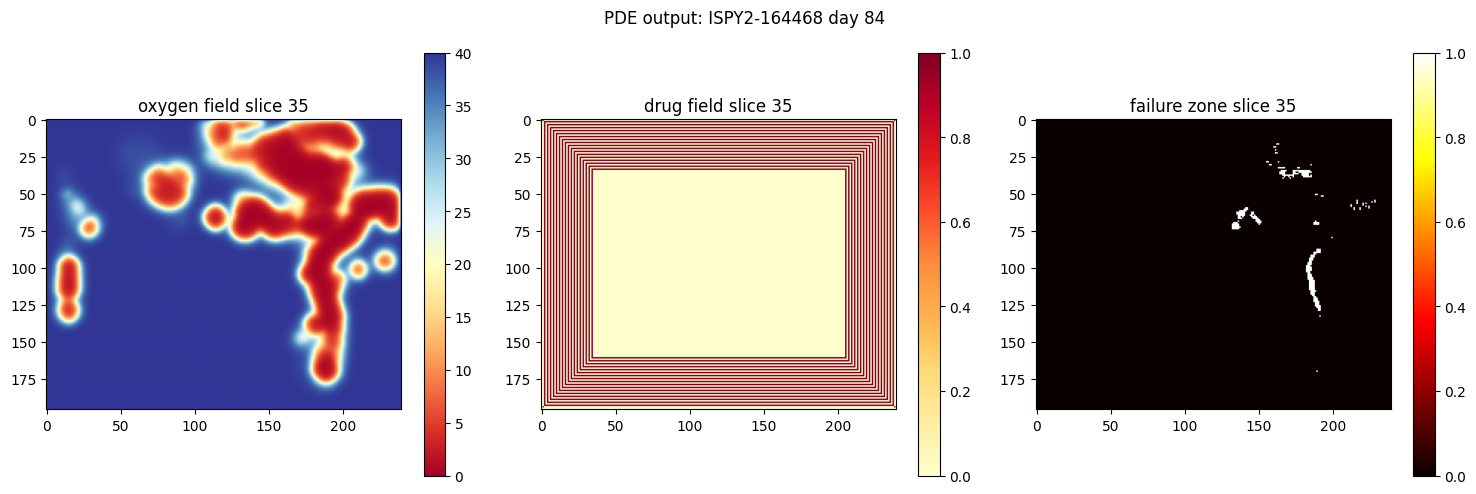

In [86]:
# 13. visualise failure zone at final time point

mid_slice = mask_crop.shape[0] // 2
final_fz = failure_zones[-1]
final_c = c_hist[-1]
final_d = d_hist[-1]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im0 = axes[0].imshow(final_c[mid_slice], cmap="RdYlBu", vmin=0, vmax=params["c0"])
axes[0].set_title("oxygen field slice " + str(mid_slice))
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(final_d[mid_slice], cmap="YlOrRd", vmin=0, vmax=params["d_peak"])
axes[1].set_title("drug field slice " + str(mid_slice))
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(final_fz[mid_slice], cmap="hot")
axes[2].set_title("failure zone slice " + str(mid_slice))
plt.colorbar(im2, ax=axes[2])

plt.suptitle("PDE output: ISPY2-164468 day 84")
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "pde_output_164468.png"), dpi=300)
plt.show()

In [90]:
# 13b. check drug field values

print("drug field min:", d_hist[-1].min())
print("drug field max:", d_hist[-1].max())
print("drug field mean inside tumor:", d_hist[-1][mask_crop > 0].mean())
print("drug field mean outside tumor:", d_hist[-1][mask_crop == 0].mean())
print("oxygen field mean inside tumor:", c_hist[-1][mask_crop > 0].mean())
print("oxygen field mean outside tumor:", c_hist[-1][mask_crop == 0].mean())

drug field min: 0.0
drug field max: 1.0
drug field mean inside tumor: 0.5011047
drug field mean outside tumor: 0.46590146
oxygen field mean inside tumor: 0.68415153
oxygen field mean outside tumor: 32.52892


In [91]:
# 14. run pde solver for all patients and collect failure zone volumes

all_results = []

for idx, row in fixed_df[fixed_df["status"] == "ok"].iterrows():
    patient_id = row["patient_id"]
    pid = row["pid"]

    mask_file = os.path.join(processed_path, "tumor_mask_" + pid + "_T0.npy")
    if not os.path.exists(mask_file):
        continue

    tumor_mask = np.load(mask_file)
    ps = float(summary[summary["patient_id"] == patient_id]["pixel_spacing_mm"].values[0])
    st = float(summary[summary["patient_id"] == patient_id]["slice_thickness_mm"].values[0])

    print("running:", patient_id)
    n_h, c_h, d_h, mask_c = run_pde_solver(tumor_mask, params_sim, ps, st)
    fz = compute_failure_zone(c_h, d_h, params_sim, mask_c)

    voxel_vol = (ps * ps * st) / 1000
    fz_volume_cc = np.sum(fz[-1]) * voxel_vol
    tumor_volume_cc = np.sum(mask_c) * voxel_vol
    fz_fraction = round(fz_volume_cc / tumor_volume_cc, 4) if tumor_volume_cc > 0 else 0

    np.save(os.path.join(processed_path, "failure_zone_" + pid + ".npy"), fz[-1])

    all_results.append({
        "patient_id": patient_id,
        "pid": pid,
        "fz_volume_cc": round(fz_volume_cc, 4),
        "fz_voxels": int(np.sum(fz[-1])),
        "tumor_volume_cc": round(tumor_volume_cc, 4),
        "fz_fraction": fz_fraction
    })
    print("  failure zone:", round(fz_volume_cc, 4), "cc, fraction:", fz_fraction)

pde_df = pd.DataFrame(all_results)
pde_df.to_csv(os.path.join(processed_path, "pde_results.csv"), index=False)
print("all done")

running: ISPY2-164468
  failure zone: 15.4554 cc, fraction: 0.4831
running: ISPY2-196024
  failure zone: 7.9153 cc, fraction: 0.4591
running: ISPY2-208303
  failure zone: 2.5503 cc, fraction: 0.4085
running: ISPY2-252748
  failure zone: 8.9701 cc, fraction: 0.4967
running: ISPY2-489504
  failure zone: 15.6078 cc, fraction: 0.5135
running: ISPY2-535779
  failure zone: 1.0394 cc, fraction: 0.378
running: ISPY2-564234
  failure zone: 6.5569 cc, fraction: 0.489
running: ISPY2-578975
  failure zone: 17.8737 cc, fraction: 0.5273
running: ISPY2-622315
  failure zone: 15.1823 cc, fraction: 0.3995
running: ISPY2-625854
  failure zone: 1.0426 cc, fraction: 0.487
running: ISPY2-697098
  failure zone: 11.0504 cc, fraction: 0.4488
running: ISPY2-727804
  failure zone: 10.9601 cc, fraction: 0.4424
running: ISPY2-829491
  failure zone: 2.7578 cc, fraction: 0.5064
running: ISPY2-910706
  failure zone: 19.6523 cc, fraction: 0.4857
running: ISPY2-934906
  failure zone: 2.7053 cc, fraction: 0.4647
all do

In [93]:
# 15. merge pde results with clinical data

clinical = pd.read_csv(os.path.join(processed_path, "tnbc_imaging_clinical.csv"))

pde_clinical = pd.merge(pde_df, clinical[["patient_id", "pCR", "Age_at_Screening", "SPHERICITY_T0", "LD_T0"]], on="patient_id", how="left")
pde_clinical.to_csv(os.path.join(processed_path, "pde_clinical_merged.csv"), index=False)

print(pde_clinical[["patient_id", "fz_volume_cc", "fz_fraction", "tumor_volume_cc", "pCR", "SPHERICITY_T0"]])

      patient_id  fz_volume_cc  fz_fraction  tumor_volume_cc  pCR  \
0   ISPY2-164468       15.4554       0.4831          31.9952    0   
1   ISPY2-196024        7.9153       0.4591          17.2423    0   
2   ISPY2-208303        2.5503       0.4085           6.2437    1   
3   ISPY2-252748        8.9701       0.4967          18.0586    1   
4   ISPY2-489504       15.6078       0.5135          30.3938    1   
5   ISPY2-535779        1.0394       0.3780           2.7499    0   
6   ISPY2-564234        6.5569       0.4890          13.4077    1   
7   ISPY2-578975       17.8737       0.5273          33.8986    1   
8   ISPY2-622315       15.1823       0.3995          38.0043    0   
9   ISPY2-625854        1.0426       0.4870           2.1408    1   
10  ISPY2-697098       11.0504       0.4488          24.6226    1   
11  ISPY2-727804       10.9601       0.4424          24.7735    1   
12  ISPY2-829491        2.7578       0.5064           5.4458    0   
13  ISPY2-910706       19.6523    

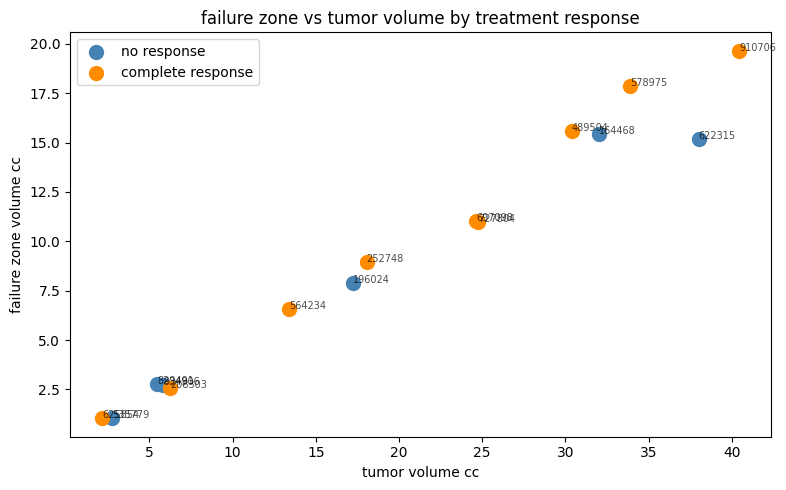

In [94]:
# 16. plot failure zone volume by treatment response

resp = pde_clinical[pde_clinical["pCR"] == 1]
non_resp = pde_clinical[pde_clinical["pCR"] == 0]

plt.figure(figsize=(8, 5))
plt.scatter(non_resp["tumor_volume_cc"], non_resp["fz_volume_cc"],
            color="steelblue", label="no response", s=100)
plt.scatter(resp["tumor_volume_cc"], resp["fz_volume_cc"],
            color="darkorange", label="complete response", s=100)

for i, row in pde_clinical.iterrows():
    plt.annotate(row["pid"], (row["tumor_volume_cc"], row["fz_volume_cc"]), fontsize=7, alpha=0.7)

plt.xlabel("tumor volume cc")
plt.ylabel("failure zone volume cc")
plt.title("failure zone vs tumor volume by treatment response")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "failure_zone_vs_response.png"), dpi=300)
plt.show()

In [97]:
# 17. ml classifier setup

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

features = ["fz_volume_cc", "tumor_volume_cc", "SPHERICITY_T0_x",
            "LD_T0_x", "VOLUME_TUM_BLU_V10", "FTV_pch_T0_T1", "fz_fraction"]

ml_clean = ml_data[features + ["pCR_x"]].dropna()
ml_clean = ml_clean.rename(columns={
    "pCR_x": "pCR",
    "SPHERICITY_T0_x": "SPHERICITY_T0",
    "LD_T0_x": "LD_T0"
})

features_clean = ["fz_volume_cc", "tumor_volume_cc", "SPHERICITY_T0",
                  "LD_T0", "VOLUME_TUM_BLU_V10", "FTV_pch_T0_T1", "fz_fraction"]

print("patients for ml:", len(ml_clean))
print("complete response:", ml_clean["pCR"].sum())
print("no response:", (ml_clean["pCR"] == 0).sum())

patients for ml: 15
complete response: 9
no response: 6


In [98]:
# 18. train random forest with leave one out cross validation

X = ml_clean[features_clean].values
y = ml_clean["pCR"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

loo = LeaveOneOut()
rf = RandomForestClassifier(n_estimators=100, random_state=42)

y_true = []
y_prob = []

for train_idx, test_idx in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    rf.fit(X_train, y_train)
    prob = rf.predict_proba(X_test)[0][1]
    y_true.append(y_test[0])
    y_prob.append(prob)

auc = roc_auc_score(y_true, y_prob)
print("random forest LOO AUC:", round(auc, 4))

random forest LOO AUC: 0.7593


In [99]:
# 19. train logistic regression for comparison

lr = LogisticRegression(random_state=42, max_iter=1000)

y_true_lr = []
y_prob_lr = []

for train_idx, test_idx in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    lr.fit(X_train, y_train)
    prob = lr.predict_proba(X_test)[0][1]
    y_true_lr.append(y_test[0])
    y_prob_lr.append(prob)

auc_lr = roc_auc_score(y_true_lr, y_prob_lr)
print("logistic regression LOO AUC:", round(auc_lr, 4))

logistic regression LOO AUC: 0.7963


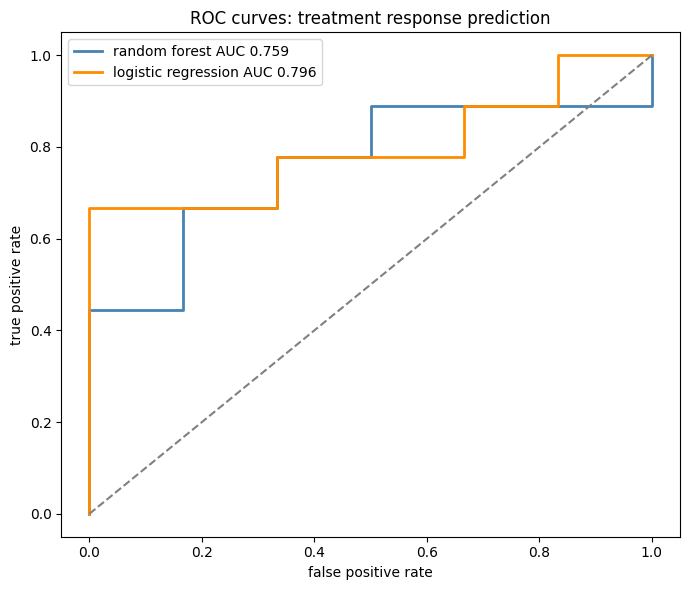

In [100]:
# 20. plot roc curves for both models

fpr_rf, tpr_rf, _ = roc_curve(y_true, y_prob)
fpr_lr, tpr_lr, _ = roc_curve(y_true_lr, y_prob_lr)

plt.figure(figsize=(7, 6))
plt.plot(fpr_rf, tpr_rf, color="steelblue", lw=2,
         label="random forest AUC " + str(round(auc, 3)))
plt.plot(fpr_lr, tpr_lr, color="darkorange", lw=2,
         label="logistic regression AUC " + str(round(auc_lr, 3)))
plt.plot([0, 1], [0, 1], color="gray", linestyle="dashed")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC curves: treatment response prediction")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "roc_curves.png"), dpi=300)
plt.show()

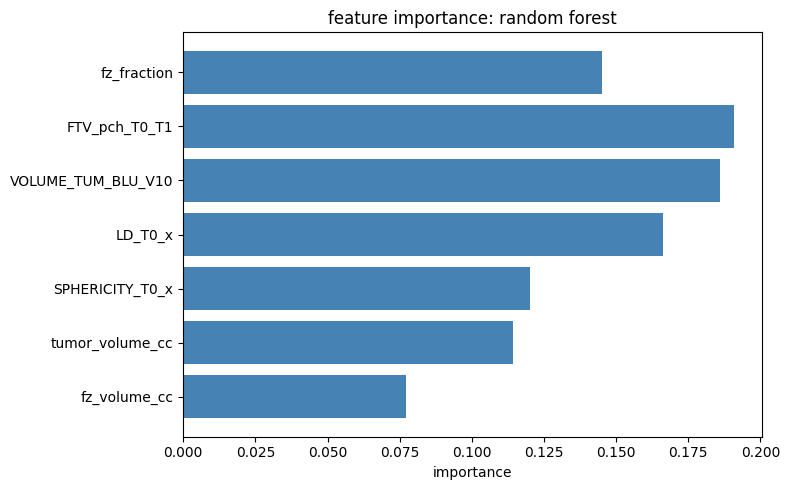

In [101]:
# 21. feature importance from random forest

rf.fit(X_scaled, y)
importances = rf.feature_importances_

plt.figure(figsize=(8, 5))
plt.barh(features, importances, color="steelblue")
plt.xlabel("importance")
plt.title("feature importance: random forest")
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "feature_importance.png"), dpi=300)
plt.show()